In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
df = pd.read_csv('Car_sales - 1656244153716.csv')

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Manufacturer            157 non-null    object 
 1   Model                   157 non-null    object 
 2   Sales_in_thousands      157 non-null    float64
 3   four_year_resale_value  121 non-null    float64
 4   Vehicle_type            157 non-null    object 
 5   Price_in_thousands      155 non-null    float64
 6   Engine_size             156 non-null    float64
 7   Horsepower              156 non-null    float64
 8   Wheelbase               156 non-null    float64
 9   Width                   156 non-null    float64
 10  Length                  156 non-null    float64
 11  Curb_weight             155 non-null    float64
 12  Fuel_capacity           156 non-null    float64
 13  Fuel_efficiency         154 non-null    float64
 14  Latest_Launch           157 non-null    ob

In [30]:
df.head()

,Manufacturer,Model,Sales_in_thousands,four_year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
0,Acura,Integra,16.919,16.360,Passenger,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2/2/2012,58.280150
1,Acura,TL,39.384,19.875,Passenger,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,6/3/2011,91.370778
2,Acura,CL,14.114,18.225,Passenger,NaN,3.2,225.0,106.9,70.6,192.0,3.470,17.2,26.0,1/4/2012,NaN
3,Acura,RL,8.588,29.725,Passenger,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,3/10/2011,91.389779
4,Audi,A4,20.397,22.255,Passenger,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,10/8/2011,62.777639


#### Observations:

1. There are missings in the data
2. Mix of numerical & non-numerical type

In [31]:
df.describe()

,Sales_in_thousands,four_year_resale_value,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Power_perf_factor
count,157.000000,121.000000,155.000000,156.000000,156.000000,156.000000,156.000000,156.000000,155.000000,156.000000,154.000000,155.000000
mean,52.998076,18.072975,27.390755,3.060897,185.948718,107.487179,71.150000,187.343590,3.378026,17.951923,23.844156,77.043591
std,68.029422,11.453384,14.351653,1.044653,56.700321,7.641303,3.451872,13.431754,0.630502,3.887921,4.282706,25.142664
min,0.110000,5.160000,9.235000,1.000000,55.000000,92.600000,62.600000,149.400000,1.895000,10.300000,15.000000,23.276272
25%,14.114000,11.260000,18.017500,2.300000,149.500000,103.000000,68.400000,177.575000,2.971000,15.800000,21.000000,60.407707
50%,29.450000,14.180000,22.799000,3.000000,177.500000,107.000000,70.550000,187.900000,3.342000,17.200000,24.000000,72.030917
75%,67.956000,19.875000,31.947500,3.575000,215.000000,112.200000,73.425000,196.125000,3.799500,19.575000,26.000000,89.414878
max,540.561000,67.550000,85.500000,8.000000,450.000000,138.700000,79.900000,224.500000,5.572000,32.000000,45.000000,188.144323


#### Observations:

1. There are outliers in the data (excluding the target)

In [32]:
df.describe(include='object')

,Manufacturer,Model,Vehicle_type,Latest_Launch
count,157,157,157,157
unique,30,156,2,130
top,Ford,Neon,Passenger,1/29/2012
freq,11,2,116,2


#### Observation:

1. Drop Model and Latest_Launch (high cardinality)

In [33]:
# Checking out duplicates

df.duplicated().sum()

np.int64(0)

In [34]:
# Dropping the Model and Latest_Launch

df.drop(columns=['Model', 'Latest_Launch'], inplace=True)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Manufacturer            157 non-null    object 
 1   Sales_in_thousands      157 non-null    float64
 2   four_year_resale_value  121 non-null    float64
 3   Vehicle_type            157 non-null    object 
 4   Price_in_thousands      155 non-null    float64
 5   Engine_size             156 non-null    float64
 6   Horsepower              156 non-null    float64
 7   Wheelbase               156 non-null    float64
 8   Width                   156 non-null    float64
 9   Length                  156 non-null    float64
 10  Curb_weight             155 non-null    float64
 11  Fuel_capacity           156 non-null    float64
 12  Fuel_efficiency         154 non-null    float64
 13  Power_perf_factor       155 non-null    float64
dtypes: float64(12), object(2)
memory usage: 17

In [36]:
# Handle the missings

obj_columns = df.select_dtypes(include='object').columns
num_columns = df.select_dtypes(exclude='object').columns

def handle_missings(x):
    return x.fillna(x.mean())

df.loc[:, num_columns] = df[num_columns].apply(handle_missings)


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Manufacturer            157 non-null    object 
 1   Sales_in_thousands      157 non-null    float64
 2   four_year_resale_value  157 non-null    float64
 3   Vehicle_type            157 non-null    object 
 4   Price_in_thousands      157 non-null    float64
 5   Engine_size             157 non-null    float64
 6   Horsepower              157 non-null    float64
 7   Wheelbase               157 non-null    float64
 8   Width                   157 non-null    float64
 9   Length                  157 non-null    float64
 10  Curb_weight             157 non-null    float64
 11  Fuel_capacity           157 non-null    float64
 12  Fuel_efficiency         157 non-null    float64
 13  Power_perf_factor       157 non-null    float64
dtypes: float64(12), object(2)
memory usage: 17

In [ ]:
# Handle the outliers (excluding target) - percentile rule, iqr rule, z_score rule
X_num = num_columns.difference(['Sales_in_thousands'])

def outlier_handling(x): # pecentile rule - replace it with iqr or z_score rule
    lc = x.quantile(0.01)
    uc = x.quantile(0.99)

    return x.clip(lc, uc)

df.loc[:, X_num] = df[X_num].apply(outlier_handling)


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Manufacturer            157 non-null    object 
 1   Sales_in_thousands      157 non-null    float64
 2   four_year_resale_value  157 non-null    float64
 3   Vehicle_type            157 non-null    object 
 4   Price_in_thousands      157 non-null    float64
 5   Engine_size             157 non-null    float64
 6   Horsepower              157 non-null    float64
 7   Wheelbase               157 non-null    float64
 8   Width                   157 non-null    float64
 9   Length                  157 non-null    float64
 10  Curb_weight             157 non-null    float64
 11  Fuel_capacity           157 non-null    float64
 12  Fuel_efficiency         157 non-null    float64
 13  Power_perf_factor       157 non-null    float64
dtypes: float64(12), object(2)
memory usage: 17

In [40]:
df.describe()

,Sales_in_thousands,four_year_resale_value,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Power_perf_factor
count,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.00000,157.000000,157.000000,157.000000,157.000000,157.000000
mean,52.998076,18.030044,27.327842,3.050146,185.322985,107.435969,71.16949,187.332558,3.379148,17.947847,23.767723,76.852889
std,68.029422,9.758199,13.966065,0.979106,52.633251,7.396840,3.37926,13.073761,0.617754,3.806720,3.956172,23.690228
min,0.110000,6.736400,10.251160,1.556000,96.480000,92.880000,66.09200,154.968000,2.245600,11.900000,15.000000,38.528203
25%,14.114000,12.545000,18.145000,2.300000,150.000000,103.000000,68.40000,177.600000,2.975000,15.800000,21.000000,60.727447
50%,29.450000,17.710000,23.400000,3.000000,180.000000,107.000000,70.60000,187.800000,3.368000,17.200000,24.000000,72.290355
75%,67.956000,18.140000,31.930000,3.500000,215.000000,112.200000,73.40000,196.100000,3.778000,19.500000,26.000000,89.401935
max,540.561000,59.491000,78.327200,5.700000,325.400000,134.300000,79.18800,219.216000,5.396520,30.880000,33.000000,141.118657


C:\Users\abhis\AppData\Local\Temp\ipykernel_29376\2092648175.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.Sales_in_thousands, kde=True)


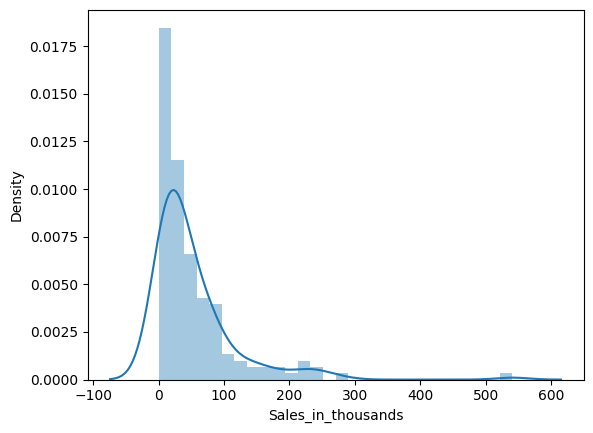

In [42]:
# Checking if the target is normally distributed

sns.distplot(df.Sales_in_thousands, kde=True)
plt.show()

C:\Users\abhis\AppData\Local\Temp\ipykernel_29376\1070111571.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(np.log(df.Sales_in_thousands), kde=True)


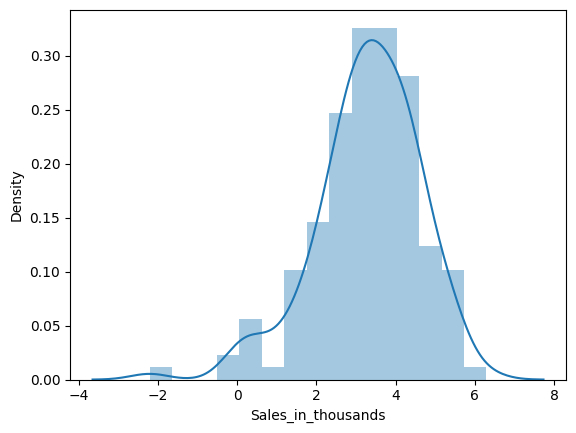

In [ ]:
# A log transformations helps in case of skewed data - make sure to add 1 to the column in case we have 0 within the column.
sns.distplot(np.log(df.Sales_in_thousands), kde=True)
plt.show()

In [ ]:
df['Sales_in_thousands'] = np.log(df.Sales_in_thousands)

In [ ]:
# Encoding of data - categorical variables
df = pd.get_dummies(df, columns=obj_columns, drop_first=True)  # HW: Why are we using drop_first=True

In [52]:
# Split the data.
from sklearn.model_selection import train_test_split

X = df[df.columns.difference(['Sales_in_thousands'])]
y = df.Sales_in_thousands

train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.3)

In [53]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(train_X, train_y) # learning from data


LinearRegression()

In [ ]:
lr.score(train_X, train_y) # R-sq.

0.7483170354143734

In [56]:
lr.score(test_X, test_y) # R-sq.

0.33252022258199554